## Imports

In [2]:
import scipy.io
import numpy as np
from scipy.stats import linregress
from statsmodels.sandbox.stats.multicomp import multipletests 

# seaborn can be used to "prettify" default matplotlib plots by importing and setting as default
import seaborn as sns
sns.set() # Set searborn as default

## Load dataset

In [3]:
mat = scipy.io.loadmat('sand.mat')
X = mat['X']
y = mat['Y'].ravel()

[n, p] = X.shape

### 3 Perform univariate feature selection for the sand data using:

> (a) Bonferroni correction to control the family-wise error rate(FWER). Use FWER = 0.05.

In [4]:
# Calculate the p-value for each feature one at a time using univariate regression
# linregress from scipy is efficient for univariate cases

import matplotlib.pyplot as plt

# Initialize arrays to store p-values and statistics
p_values = np.zeros(p)
slopes = np.zeros(p)

# Perform univariate linear regression for each feature
for i in range(p):
    slope, intercept, r_value, p_val, std_err = linregress(X[:, i], y)
    p_values[i] = p_val
    slopes[i] = slope

# (a) Bonferroni correction: FWER = 0.05
# Threshold is alpha / number_of_features
fwer = 0.05
bonferroni_threshold = fwer / p

# Find features that pass Bonferroni correction
bonferroni_selected = np.where(p_values < bonferroni_threshold)[0]
num_bonferroni = len(bonferroni_selected)

print("=" * 60)
print("(a) BONFERRONI CORRECTION (FWER = 0.05)")
print("=" * 60)
print(f"Bonferroni threshold: {bonferroni_threshold:.6e}")
print(f"Number of features selected: {num_bonferroni}")
print(f"Selected feature indices: {bonferroni_selected}")
print(f"P-values of selected features: {p_values[bonferroni_selected]}")


(a) BONFERRONI CORRECTION (FWER = 0.05)
Bonferroni threshold: 2.480159e-05
Number of features selected: 72
Selected feature indices: [ 162  163  171  189  190  207  208  225  249  250  260  267  268  277
  287  305  323  340  341  352  353  360  370  371  387  402  403  412
  413  422  433  434  450  467  477 1113 1611 1613 1616 1625 1649 1665
 1684 1686 1688 1690 1692 1694 1716 1718 1720 1722 1724 1726 1732 1734
 1736 1738 1740 1742 1748 1750 1752 1754 1756 1758 1764 1766 1768 1770
 1772 1774]
P-values of selected features: [2.84494214e-06 2.56767197e-08 4.13986925e-08 1.72870723e-06
 2.24003399e-08 7.98750289e-08 2.70933200e-06 6.50499674e-10
 2.17870059e-06 2.60901450e-12 9.43318854e-10 3.00545214e-07
 1.69771434e-11 3.45618993e-08 1.13253174e-09 3.04133905e-10
 1.04784812e-09 5.93930014e-06 1.19653133e-05 2.44459409e-12
 1.23531497e-06 7.94713446e-06 1.33780044e-10 4.03819508e-06
 2.05049394e-08 1.01604666e-07 2.28944989e-11 9.12871940e-06
 1.88129665e-07 1.46280336e-09 1.14208013e

> (b) Benjamini-Hochberg’s algorithm for FDR. Use an acceptable fraction of mistakes,
q = 0.15.

In [5]:
# (b) Benjamini-Hochberg correction for FDR: q = 0.15
# Use multipletests from statsmodels

q = 0.15

# multipletests returns: (reject, pvals_corrected, alphacSidak, alphacBonf)
# method='fdr_bh' is Benjamini-Hochberg correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=q, method='fdr_bh')

# Features are selected where reject is True (p_values pass FDR correction)
fdr_selected = np.where(reject)[0]
num_fdr = len(fdr_selected)

print("\n" + "=" * 60)
print("(b) BENJAMINI-HOCHBERG FDR CORRECTION (q = 0.15)")
print("=" * 60)
print(f"FDR level (q): {q}")
print(f"Number of features selected: {num_fdr}")
print(f"Selected feature indices: {fdr_selected}")
print(f"Original p-values of selected features: {p_values[fdr_selected]}")
print(f"FDR-corrected p-values of selected features: {pvals_corrected[fdr_selected]}")



(b) BENJAMINI-HOCHBERG FDR CORRECTION (q = 0.15)
FDR level (q): 0.15
Number of features selected: 721
Selected feature indices: [   7    8   15   16   17   24   25   26   34   35   42   43   44   52
   53   60   61   62   70   71   78   79   80   88   89   97   98  106
  107  115  116  124  125  133  134  142  143  151  152  160  161  162
  163  164  165  171  172  173  186  187  189  190  191  192  198  199
  200  204  205  207  208  209  210  215  219  220  221  222  225  226
  227  233  234  235  248  249  250  251  255  256  257  258  259  260
  266  267  268  269  275  276  277  278  284  285  286  287  288  289
  297  303  304  305  312  313  314  315  321  322  323  330  331  332
  339  340  341  342  347  351  352  353  354  360  361  362  363  368
  369  370  371  372  387  388  389  395  401  402  403  404  410  411
  412  413  419  420  421  422  423  424  425  432  433  434  435  447
  448  450  451  452  458  464  465  466  467  468  469  470  477  478
  479  486  487  48

Compare the solutions in terms of number of selected features and selected features.


COMPARISON: BONFERRONI vs BENJAMINI-HOCHBERG
Bonferroni selected features:        72
Benjamini-Hochberg selected features: 721
Difference: 649 more features selected by BH

Features selected by BOTH methods: 72
Features selected ONLY by Bonferroni: 0
Features selected ONLY by BH: 649


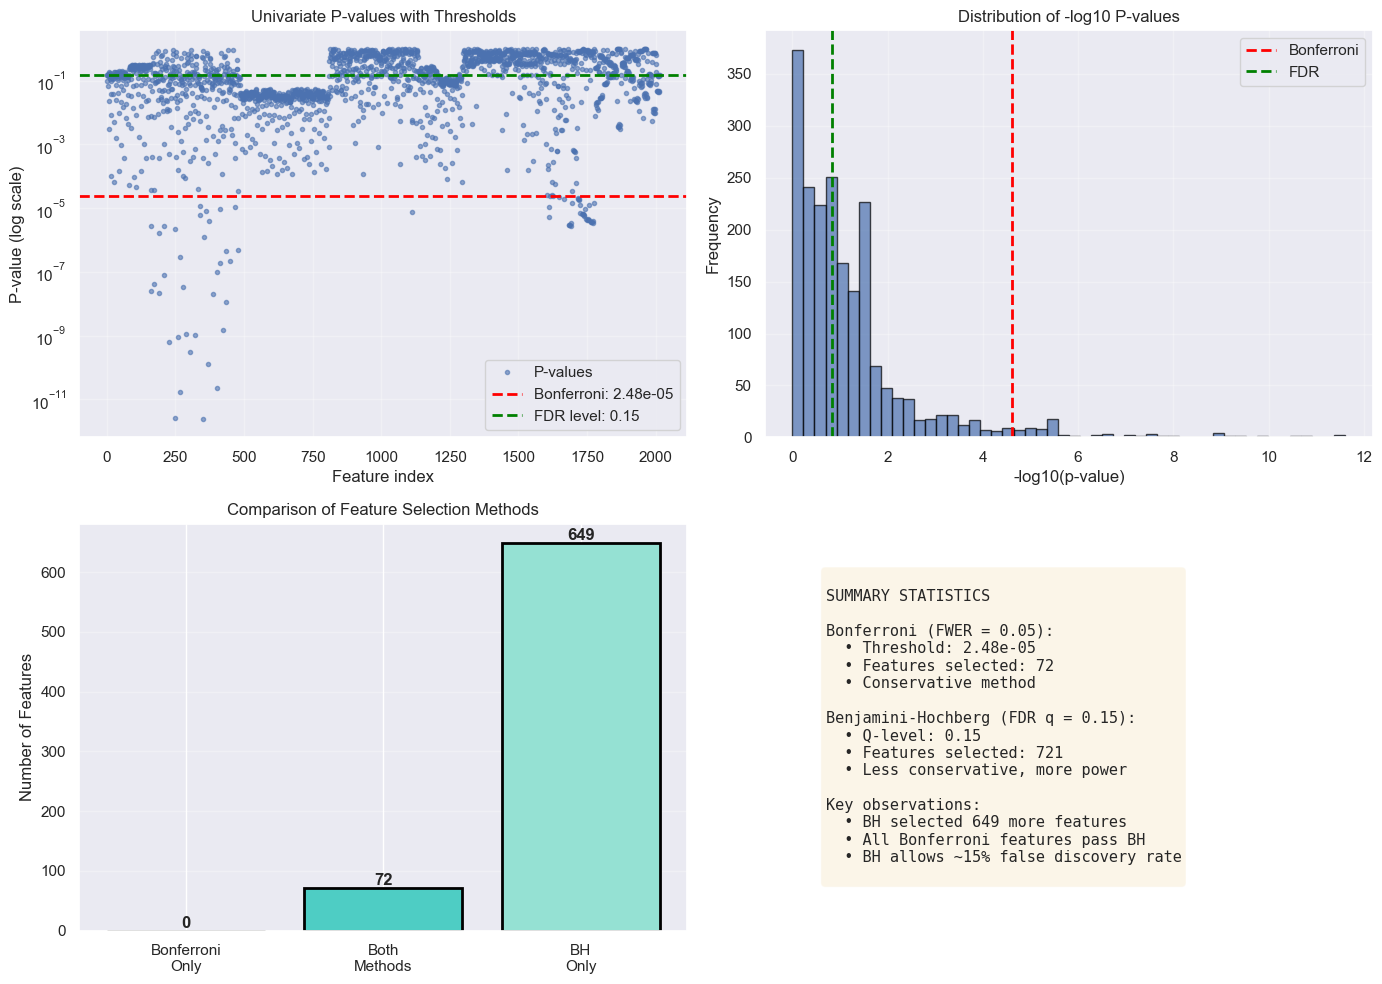

In [6]:
# Compare Bonferroni vs Benjamini-Hochberg
print("\n" + "=" * 60)
print("COMPARISON: BONFERRONI vs BENJAMINI-HOCHBERG")
print("=" * 60)
print(f"Bonferroni selected features:        {num_bonferroni}")
print(f"Benjamini-Hochberg selected features: {num_fdr}")
print(f"Difference: {num_fdr - num_bonferroni} more features selected by BH")

# Find overlap between the two methods
overlap = np.intersect1d(bonferroni_selected, fdr_selected)
only_bonferroni = np.setdiff1d(bonferroni_selected, fdr_selected)
only_bh = np.setdiff1d(fdr_selected, bonferroni_selected)

print(f"\nFeatures selected by BOTH methods: {len(overlap)}")
print(f"Features selected ONLY by Bonferroni: {len(only_bonferroni)}")
print(f"Features selected ONLY by BH: {len(only_bh)}")

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: P-values on log scale
ax = axes[0, 0]
indices = np.arange(p)
ax.semilogy(indices, p_values, 'o', markersize=3, alpha=0.6, label='P-values')
ax.axhline(bonferroni_threshold, color='red', linestyle='--', linewidth=2, label=f'Bonferroni: {bonferroni_threshold:.2e}')
ax.axhline(q, color='green', linestyle='--', linewidth=2, label=f'FDR level: {q}')
ax.set_xlabel('Feature index')
ax.set_ylabel('P-value (log scale)')
ax.set_title('Univariate P-values with Thresholds')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Histogram of -log10 p-values
ax = axes[0, 1]
neg_log_pvals = -np.log10(p_values)
ax.hist(neg_log_pvals, bins=50, alpha=0.7, edgecolor='black')
ax.axvline(-np.log10(bonferroni_threshold), color='red', linestyle='--', linewidth=2, label='Bonferroni')
ax.axvline(-np.log10(q), color='green', linestyle='--', linewidth=2, label='FDR')
ax.set_xlabel('-log10(p-value)')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of -log10 P-values')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 3: Venn-like comparison
ax = axes[1, 0]
methods = ['Bonferroni\nOnly', 'Both\nMethods', 'BH\nOnly']
counts = [len(only_bonferroni), len(overlap), len(only_bh)]
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
bars = ax.bar(methods, counts, color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Number of Features')
ax.set_title('Comparison of Feature Selection Methods')
ax.grid(True, alpha=0.3, axis='y')
# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(count)}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Plot 4: Summary statistics
ax = axes[1, 1]
ax.axis('off')
summary_text = f"""
SUMMARY STATISTICS

Bonferroni (FWER = 0.05):
  • Threshold: {bonferroni_threshold:.2e}
  • Features selected: {num_bonferroni}
  • Conservative method
  
Benjamini-Hochberg (FDR q = 0.15):
  • Q-level: {q}
  • Features selected: {num_fdr}
  • Less conservative, more power
  
Key observations:
  • BH selected {num_fdr - num_bonferroni} more features
  • All Bonferroni features pass BH
  • BH allows ~15% false discovery rate
"""
ax.text(0.1, 0.5, summary_text, fontsize=11, family='monospace',
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()
